# Torus example

A noisy point cloud on a torus in $\mathbb R^3$, analysed with RiePCA at a
sequence of absolute heat times. The numerical engine is
[`riepca_euclidean.py`](riepca_euclidean.py): it fits RiePCA, evaluates the
diffusion-Fréchet function, locates its local minima and selects the reference
points. This notebook supplies only the data, the settings, and the figures.

The **absolute heat time $t$** is used everywhere — no relative-time
conversion and no hidden rescaling. Values supplied in `T_VALUES` are passed
directly to

$$
k_t(x,y)=(4\pi t)^{-d/2}
\exp\!\left(-\frac{\lVert x-y\rVert^2}{4t}\right).
$$

The steps are:

1. sample the torus and fix the weights $\mu$;
2. locate the local minima of the diffusion-Fréchet function at one reference
   heat time and select reference points from their sublevel components;
3. fit RiePCA at every $t$ through `riepca_euclidean`, with the reference
   points held fixed across the sweep;
4. validate the numerical identities and visualize the components;
5. test whether PC1–PC2 carries the toroidal angle $\theta$ and PC3–PC4 the
   meridional angle $\varphi$, against Euclidean and kernel PCA baselines.

## Input contract

- `data_points`: an array of shape `(n, d)`;
- `mu`: an optional probability vector of length `n`;
- `t_values`: positive absolute heat times, in squared data-coordinate units;
- `reference_points`: either one fixed array of shape `(r, d)` used at every
  $t$, or a dictionary `{t: array}` when references are selected separately at
  each heat time. This notebook uses the fixed-array form.

## 0. The RiePCA engine

With
$\kappa_t(x,y)=(4\pi t)^{-d/2}e^{-\lVert x-y\rVert^2/4t}$, each observation $y$
becomes a vector *field* sampled at the references $x_1,\dots,x_r$:

$$g_{t,y}(x_a)=\nabla_{\!x}\kappa_t(x_a,y)=\kappa_t(x_a,y)\,\frac{y-x_a}{2t},$$

living in $H_R=(\mathbb R^d)^r$ with
$\langle U,V\rangle_R=\sum_a\omega_a\,U(x_a)^{\top}V(x_a)$.

The hard ceiling on the number of components is the **field capacity**
$\dim H_R=r\cdot d$, further capped by the rank $\,\#\{\mu_i>0\}-1$ that
centring leaves.

In [1]:
# locate and import the RiePCA engine
import sys
from pathlib import Path

_candidates = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"),
               Path.cwd() / "upload", Path("/content/drive/MyDrive/riepca")]
_home = next((p for p in _candidates if (p / "riepca_euclidean.py").exists()), None)
if _home is None:
    raise FileNotFoundError(
        "riepca_euclidean.py not found. Upload it next to this notebook and "
        "rerun this cell. Searched: " + ", ".join(str(p) for p in _candidates))
if str(_home) not in sys.path:
    sys.path.insert(0, str(_home))

import numpy as np
import riepca_euclidean
from riepca_euclidean import check_riepca, degenerate_blocks

print("riepca_euclidean loaded from", _home / "riepca_euclidean.py")

riepca_euclidean loaded from /content/riepca_euclidean.py


In [2]:
import numpy as np
from scipy.ndimage import generate_binary_structure, label
from sklearn.metrics import pairwise_distances

In [3]:
# Plotting setup: make every figure both DISPLAY and SAVE.
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Single place that controls where figures go and whether they show.
FIGURE_DIR = Path("torus_RiePCA_plots")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SHOW_FIGURES = True          # set False for headless/batch runs
SAVE_DPI = 300

# One style block, applied once.
plt.style.use("default")
mpl.rcParams.update({
    "figure.facecolor":  "white",
    "savefig.facecolor": "white",
    "savefig.bbox":      "tight",
    "savefig.dpi":       SAVE_DPI,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    12,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.6,
    "legend.frameon":    False,
    "legend.fontsize":   10,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "lines.linewidth":   1.6,
    "axes.prop_cycle":   mpl.cycler(color=[
        "#0F4C81", "#E4572E", "#17A398", "#8C4799", "#B8860B", "#5A5A5A"]),
})


def time_tag(t):
    """Return a filename-safe label for an absolute heat time."""
    return f"{float(t):g}".replace(".", "p").replace("-", "m")


def finalize(fig, name, *, subdir=None, formats=("png", "pdf")):
    """Save `fig` under FIGURE_DIR/[subdir] as `name`, then show or close it."""
    target = FIGURE_DIR if subdir is None else FIGURE_DIR / subdir
    target.mkdir(parents=True, exist_ok=True)
    written = []
    for ext in formats:
        path = target / f"{name}.{ext}"
        fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight", facecolor="white")
        written.append(path)
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)
    return written

## 1. Torus experiment

The cloud is sampled uniformly in the torus parameters $(\theta,\varphi)$, not
uniformly in surface area (`AREA_UNIFORM = False`), so the inner rim is denser per unit area than the outer rim; isotropic ambient noise of standard deviation `NOISE` is added to the coordinates.

Equip the dataset with the uniform probability distribution $\mu_i=1/n$ for each datapoint $y_i.

The analysis uses the explicit heat times in `T_VALUES`; per-time figures are
drawn only for `T_FIGURES`. The reference points are selected once, at
`T_REFERENCE`, and reused at every heat time.

### Synthetic dataset

In [4]:
# Control panel: parameters of the torus experiment

RANDOM_SEED = 40
N_POINTS = 2000
MAJOR_RADIUS = 2.0
MINOR_RADIUS = 0.8
NOISE = 0.05                  # isotropic ambient noise, standard deviation
AREA_UNIFORM = False
# False: theta and phi both uniform in [0, 2pi), which oversamples the inner
#        rim because dA = r (R + r cos phi) dphi dtheta.
# True:  rejection-samples phi so the cloud is uniform on the SURFACE.
# Report whichever is used: it changes the density, hence the diffusion-Frechet
# function, its minima and the reference points.

# Absolute heat times in squared data-coordinate units.
T_VALUES = (0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 1.2, 1.3, 1.4, 1.5,
            1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4.0,
            5.0, 7.0, 8.0, 10.0, 12.0, 15.0, 17.0, 20.0, 25.0, 30.0, 35.0,
            40.0, 45.0, 50.0)
T_FIGURES = (0.5, 2.0, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4.0, 5.0)
T_REFERENCE = 0.01            # heat time at which the reference points are fixed
TOP_K = 10
REL_EIGEN_FLOOR = 1e-12       # reporting threshold for the "significant" flag only;
                              # retention is decided by riepca_euclidean's eig_rtol
DEGENERACY_RATIO = 1.2

# Grids and reference points (arguments of riepca_euclidean.select_reference_points).
GRID_PADDING = 0.2            # absolute padding of the candidate grid, in data units
                              # (the module's default None pads by 10% of each axis range)
MODE_GRID_SHAPE = (20, 20, 20)
REFERENCE_GRID_SHAPE = (20, 20, 20)
N_REPRESENTATIVES = 25
BAND_FRACTION = 0.30          # relative_epsilon: sublevel band as a fraction of the range
                              # of the diffusion-Frechet function inside the data box
CHUNK_SIZE = 4096

TWO_PI = 2.0 * np.pi



# Dataset generation
def sample_torus(n_points, major_radius, minor_radius, noise, area_uniform, rng):
    """Torus point cloud with explicit control over the sampling measure.

    `rng` is a np.random.RandomState. RandomState(RANDOM_SEED) reproduces the
    cloud of the earlier figures exactly; switching to default_rng would change
    every figure.
    """
    theta = rng.uniform(0, TWO_PI, n_points)
    if area_uniform:
        phi, filled = np.empty(n_points), 0
        while filled < n_points:
            candidate = rng.uniform(0, TWO_PI, n_points)
            keep = candidate[
                rng.uniform(0, 1, n_points)
                < (major_radius + minor_radius * np.cos(candidate))
                / (major_radius + minor_radius)
            ]
            take = min(len(keep), n_points - filled)
            phi[filled:filled + take] = keep[:take]
            filled += take
    else:
        phi = rng.uniform(0, TWO_PI, n_points)
    x = (major_radius + minor_radius * np.cos(phi)) * np.cos(theta)
    y = (major_radius + minor_radius * np.cos(phi)) * np.sin(theta)
    z = minor_radius * np.sin(phi)
    points = np.column_stack([x, y, z]) + noise * rng.randn(n_points, 3)
    return points, theta, phi


rng = np.random.RandomState(RANDOM_SEED)
data_points, theta_values, phi_values = sample_torus(
    N_POINTS, MAJOR_RADIUS, MINOR_RADIUS, NOISE, AREA_UNIFORM, rng
)
mu = np.full(N_POINTS, 1.0 / N_POINTS)

cloud_diameter = float(pairwise_distances(data_points).max())
print("data shape:", data_points.shape)
print("mu sum:", mu.sum())
print(f"cloud diameter: {cloud_diameter:.4f}")



# Angles on the circle
def wrap_angle(angles):
    """Wrap angles into [-pi, pi)."""
    return (np.asarray(angles, float) + np.pi) % TWO_PI - np.pi


def angular_mask(angles, center, tolerance):
    """Points within `tolerance` of `center` ON THE CIRCLE.

    The naive |angle - center| < tolerance drops the half of a slice on the far
    side of the 0 / 2pi branch cut; wrapping the difference first does not.
    """
    return np.abs(wrap_angle(np.asarray(angles, float) - center)) < tolerance


def circular_association(a, b):
    """Association between two circular variables, invariant to rotation and
    to reflection, and well defined when both marginals are UNIFORM.

    A circular correlation that centres each variable on its circular mean is
    not usable here: for theta ~ Uniform(0, 2pi) that mean does not exist (the
    mean resultant length is 0.004 to 0.04), so it would centre on noise. This
    statistic does not centre:

        |mean e^{i(a-b)}|   detects a rotation      (orientation preserved)
        |mean e^{i(a+b)}|   detects a reflection    (orientation reversed)

    1 = one angle determines the other, 0 = no association.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(max(abs(np.mean(np.exp(1j * (a - b)))),
                     abs(np.mean(np.exp(1j * (a + b))))))


# Sanity check on the sampling measure: for an area-uniform torus the count
# ratio between the inner rim (phi = pi) and the outer rim (phi = 0) is
# (R - r)/(R + r); parameter-uniform sampling gives 1. The bins hold about
# 190 points each, so the ratio carries a sampling error of about 0.09.
inner = angular_mask(phi_values, np.pi, 0.3).sum()
outer = angular_mask(phi_values, 0.0, 0.3).sum()
ratio = inner / outer
ratio_se = ratio * np.sqrt(1.0 / inner + 1.0 / outer)
print(f"inner/outer rim count ratio {ratio:.3f} +/- {ratio_se:.3f} (sampling)"
      f"   (area-uniform would be "
      f"{(MAJOR_RADIUS - MINOR_RADIUS) / (MAJOR_RADIUS + MINOR_RADIUS):.3f},"
      f" parameter-uniform 1.0)")

data shape: (2000, 3)
mu sum: 1.0000000000000004
cloud diameter: 5.7860
inner/outer rim count ratio 0.839 +/- 0.088 (sampling)   (area-uniform would be 0.429, parameter-uniform 1.0)


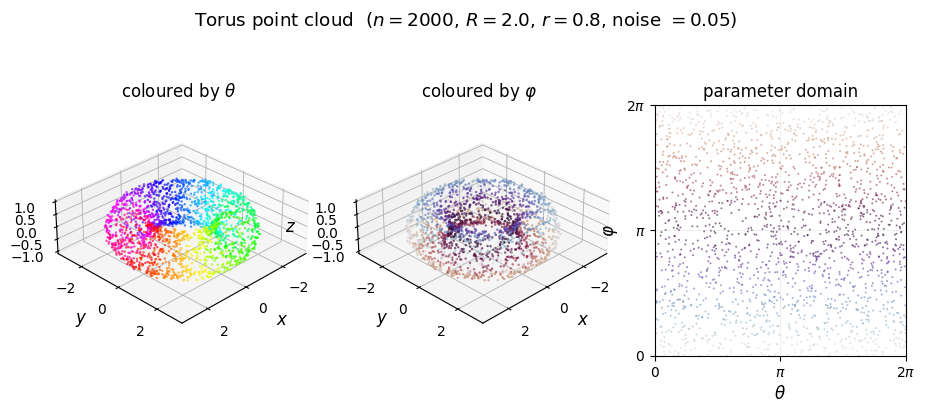

[PosixPath('torus_RiePCA_plots/Data/dataset_point_cloud.png'),
 PosixPath('torus_RiePCA_plots/Data/dataset_point_cloud.pdf')]

In [5]:
# Dataset plots
fig = plt.figure(figsize=(11, 4.2))

ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
           c=theta_values, cmap="hsv", s=3, alpha=0.7, edgecolors="none",
           rasterized=True)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_title(r"coloured by $\theta$")

ax = fig.add_subplot(1, 3, 2, projection="3d")
ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
           c=phi_values, cmap="twilight", s=3, alpha=0.7, edgecolors="none",
           rasterized=True)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_title(r"coloured by $\varphi$")

ax = fig.add_subplot(1, 3, 3)
ax.scatter(theta_values, phi_values, c=phi_values, cmap="twilight", s=2,
           alpha=0.6, edgecolors="none", rasterized=True)
ax.set(xlabel=r"$\theta$", ylabel=r"$\varphi$", xlim=(0, TWO_PI), ylim=(0, TWO_PI))
ax.set_xticks([0, np.pi, TWO_PI]); ax.set_xticklabels(["$0$", r"$\pi$", r"$2\pi$"])
ax.set_yticks([0, np.pi, TWO_PI]); ax.set_yticklabels(["$0$", r"$\pi$", r"$2\pi$"])
ax.set_aspect("equal"); ax.set_title("parameter domain")

fig.suptitle(f"Torus point cloud  ($n={N_POINTS}$, $R={MAJOR_RADIUS}$, "
             f"$r={MINOR_RADIUS}$, noise $={NOISE}$)", y=1.02)
finalize(fig, "dataset_point_cloud", subdir="Data")

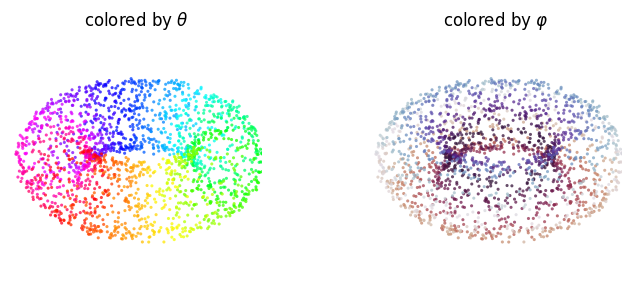

[PosixPath('torus_RiePCA_plots/Data/dataset_point_cloud_paper.png'),
 PosixPath('torus_RiePCA_plots/Data/dataset_point_cloud_paper.pdf')]

In [6]:
# Paper version: two panels, no axes, filling the figure.
fig = plt.figure(figsize=(7.2, 2.8))
axis_positions = [[0.00, 0.00, 0.50, 0.90], [0.50, 0.00, 0.50, 0.90]]
plot_settings = [(theta_values, "hsv", r"colored by $\theta$"),
                 (phi_values, "twilight", r"colored by $\varphi$")]
for position, (colour, cmap, title) in zip(axis_positions, plot_settings):
    ax = fig.add_axes(position, projection="3d")
    ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
               c=colour, cmap=cmap, s=5, alpha=0.75, edgecolors="none",
               rasterized=True)
    ax.set_box_aspect([1, 1, 0.35], zoom=1.45)   # zoom enlarges the torus
    ax.view_init(elev=30, azim=45)
    ax.margins(0)
    ax.set_axis_off()
    ax.set_facecolor("none")
    ax.set_title(title, pad=-4)
finalize(fig, "dataset_point_cloud_paper", subdir="Data")

### The diffusion-Fréchet function and its minima

The difusion Fréchet function at heat time $t$ is

$$
F_t(x)=\sum_i\mu_i\,d_t(x,y_i)^2
      =2\,k_{2t}(x,x)-2\sum_i\mu_i\,k_{2t}(x,y_i),
$$

because $d_t(x,y)^2=k_{2t}(x,x)+k_{2t}(y,y)-2k_{2t}(x,y)$ and
$k_{2t}(x,x)=(8\pi t)^{-d/2}$ is constant in $x$. Minimising $V_t$ is equivalent to maximize the heat kernel density estimator $\sum_i\mu_i k_{2t}(x,y_i)$; both are implemented in `riepca_euclidean`:

- `diffusion_frechet_values(x, data_points, t, mu=mu)` evaluates $F_t(x)$
  with the normalised kernel (the figures use it);
- `select_reference_points(..., backend="grid")` evaluates the scaled
  function $F_t/(2k_{2t}(x,x))=1-\sum_i\mu_i e^{-\lVert x-y_i\rVert^2/8t}$ on
  a padded bounding-box grid, seeds one candidate per grid-local minimum,
  refines every seed with L-BFGS-B (analytic gradient, bounded to the grid
  box), merges coincident results and sorts the minima by value. With
  `method="global_minimum"` the result carries **every** minimum found in
  `.modes` (best first), which is how the minima at the figure times are
  obtained below; `t` is the RiePCA heat time, the kernel inside is at $2t$.

In [7]:
def frechet_minima(t, *, grid_shape=MODE_GRID_SHAPE, padding=GRID_PADDING):
    """Local minima of V_t located by riepca_euclidean's grid selector.

    Returns (modes, values): the minima as an (m, d) array, best first, and
    V_t at each of them in normalised-kernel units. `method="global_minimum"`
    runs the same mode search as the reference selector and keeps every
    minimum in `.modes`; only `.reference_points` is cut to the first one.
    """
    selection = riepca_euclidean.select_reference_points(
        data_points, t, mu=mu,
        method="global_minimum", backend="grid",
        grid_shape=grid_shape, padding=padding, max_modes=None,
        chunk_size=CHUNK_SIZE,
    )
    values = riepca_euclidean.diffusion_frechet_values(
        selection.modes, data_points, t, mu=mu
    )
    return selection.modes, values


def distance_to_surface(points):
    """Distance from each point to the noise-free torus surface (R, r)."""
    p = np.atleast_2d(points)
    return np.abs(np.hypot(np.hypot(p[:, 0], p[:, 1]) - MAJOR_RADIUS, p[:, 2])
                  - MINOR_RADIUS)


modes_by_t = {t: frechet_minima(t) for t in sorted(set(T_FIGURES) | {T_REFERENCE})}

print(f"{'t':>6} {'minima':>7}   best minimum of F_t            |xy|    to surface")
for t, (modes, values) in modes_by_t.items():
    best = modes[0]
    print(f"{t:>6g} {len(modes):>7d}   ({best[0]:+.3f}, {best[1]:+.3f}, {best[2]:+.3f})"
          f"   {np.hypot(best[0], best[1]):.3f}   {distance_to_surface(best)[0]:.3f}")

     t  minima   best minimum of F_t            |xy|    to surface
  0.01      40   (-0.818, -1.078, +0.472)   1.353   0.001
   0.5       1   (+0.037, -0.331, -0.012)   0.333   0.867
     2       1   (+0.018, -0.095, -0.012)   0.096   1.104
  2.25       1   (+0.018, -0.091, -0.012)   0.093   1.107
   2.5       1   (+0.018, -0.089, -0.012)   0.091   1.109
  2.75       1   (+0.018, -0.087, -0.012)   0.089   1.111
     3       1   (+0.018, -0.085, -0.012)   0.087   1.113
  3.25       1   (+0.018, -0.084, -0.012)   0.086   1.114
   3.5       1   (+0.018, -0.083, -0.012)   0.085   1.115
  3.75       1   (+0.018, -0.082, -0.012)   0.084   1.116
     4       1   (+0.018, -0.081, -0.012)   0.083   1.117
     5       1   (+0.018, -0.078, -0.012)   0.080   1.120


### Reference points

The heat-gradient field is sampled at reference points chosen by
`riepca_euclidean.select_reference_points` with `method="epsilon_neighborhood"`
on the grid backend: sublevel components of $V_{t_{\mathrm{ref}}}$ around its
local minima, summarised by KMeans representatives snapped back to grid
points.

In [8]:
selection = riepca_euclidean.select_reference_points(
    data_points, T_REFERENCE, mu=mu,
    method="epsilon_neighborhood", backend="grid",
    grid_shape=REFERENCE_GRID_SHAPE, padding=GRID_PADDING,
    relative_epsilon=BAND_FRACTION, n_representatives=N_REPRESENTATIVES,
    max_modes=None, random_state=RANDOM_SEED, chunk_size=CHUNK_SIZE,
)
reference_points = selection.reference_points
diag = selection.diagnostics
n_grid = int(np.prod(diag["grid_shape"]))


def sublevel_component_sizes(selection):
    """Voxels in each minimum's own sublevel component, in the selector's order
    (deepest minimum first). Read off the selector's candidate values, modes
    and band with the same labelling it uses; this is a diagnostic only."""
    shape = selection.diagnostics["grid_shape"]
    band = selection.diagnostics["scaled_band"]
    values = selection.candidate_values.reshape(shape)
    axes = [np.unique(selection.candidate_points[:, j]) for j in range(len(shape))]
    sizes = []
    for mode, value in zip(selection.modes, selection.mode_values):
        labels, _ = label(values < value + band,
                          structure=generate_binary_structure(len(shape), len(shape)))
        index = tuple(int(np.argmin(np.abs(axes[j] - mode[j]))) for j in range(len(shape)))
        sizes.append(int((labels == labels[index]).sum()) if labels[index] else 0)
    return np.asarray(sizes)


component_sizes = sublevel_component_sizes(selection)
print(f"reference points fixed at t={T_REFERENCE}: {selection.n_references} points from "
      f"{diag['n_modes']} minima; {diag['n_components']} component(s), "
      f"{diag['n_selected_candidates']} of {n_grid} voxels; band = {selection.relative_epsilon:.0%} "
      f"of the range {diag['candidate_value_span']:.4g} (scaled units) measured inside the data box")
print(f"  per-minimum sublevel components: deepest {component_sizes[0]} voxels, "
      f"shallowest {component_sizes[-1]} voxels, median {int(np.median(component_sizes))}; "
      f"the union is {diag['n_selected_candidates'] / n_grid:.0%} of the padded box")

# How well do the reference points cover the surface?
reference_surface_distance = distance_to_surface(reference_points)
reference_theta = np.arctan2(reference_points[:, 1], reference_points[:, 0]) % TWO_PI
print(f"  distance to torus surface: median {np.median(reference_surface_distance):.3f}, "
      f"max {reference_surface_distance.max():.3f}")
print(f"  theta occupancy (8 bins): {np.histogram(reference_theta, 8, (0, TWO_PI))[0]}")

# The selector's own minima at T_REFERENCE agree with frechet_minima above.
same_minima = np.allclose(selection.modes, modes_by_t[T_REFERENCE][0], atol=1e-8, rtol=0)
print(f"  minima identical to the figure-time search at t={T_REFERENCE}: {same_minima}")

reference points fixed at t=0.01: 25 points from 40 minima; 1 component(s), 4795 of 8000 voxels; band = 30% of the range 0.009354 (scaled units) measured inside the data box
  per-minimum sublevel components: deepest 4 voxels, shallowest 4795 voxels, median 1598; the union is 60% of the padded box
  distance to torus surface: median 0.098, max 0.248
  theta occupancy (8 bins): [3 4 2 4 2 3 3 4]
  minima identical to the figure-time search at t=0.01: True


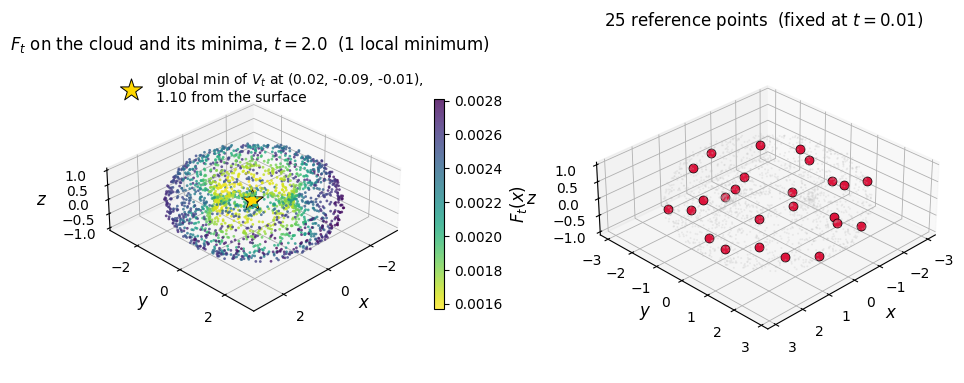

[PosixPath('torus_RiePCA_plots/Data/frechet_minima_and_reference_points.png'),
 PosixPath('torus_RiePCA_plots/Data/frechet_minima_and_reference_points.pdf')]

In [9]:
# Frechet minima and reference points
t_show = T_FIGURES[1]
F_cloud = riepca_euclidean.diffusion_frechet_values(data_points, data_points, t_show, mu=mu)
minima, _ = modes_by_t[t_show]

fig = plt.figure(figsize=(11, 4.4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
sc = ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
                c=F_cloud, cmap="viridis_r", s=4, alpha=0.8, edgecolors="none",
                rasterized=True)
for m in minima:
    ax.scatter(*m, marker="D", s=45, c="crimson", edgecolors="k",
               linewidths=0.5, depthshade=False)
best = minima[0]
ax.scatter(*best, marker="*", s=280, c="gold", edgecolors="k", linewidths=0.7,
           depthshade=False,
           label=(f"global min of $V_t$ at ({best[0]:.2f}, {best[1]:.2f}, {best[2]:.2f}),"
                  f"\n{distance_to_surface(best)[0]:.2f} from the surface"))
fig.colorbar(sc, ax=ax, shrink=0.62, pad=0.10, label=r"$F_t(x)$")
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.legend(loc="upper left")
ax.set_title(rf"$F_t$ on the cloud and its minima, $t={t_show}$"
             f"  ({len(minima)} local {'minimum' if len(minima) == 1 else 'minima'})")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
           c="0.75", s=2, alpha=0.25, edgecolors="none", rasterized=True)
ax.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2],
           c="crimson", s=42, edgecolors="k", linewidths=0.5, depthshade=False)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_title(f"{len(reference_points)} reference points  (fixed at $t={T_REFERENCE}$)")

finalize(fig, "frechet_minima_and_reference_points", subdir="Data")

### Fit RiePCA at every heat time through riepca_euclidean

The reference points are the same array at every $t$. Only the kernel weights
$\kappa_t(x_a,y)/2t$ change with $t$, so the principal fields at different
heat times are elements of one space, $(\mathbb R^3)^{25}$ (because there are 25 reference points obtained from the previous section), and the scores are
comparable up to the heat-kernel prefactor. Every fit is validated with
`check_riepca`.

In [10]:
by_t = {}
checks = {}
for t in T_VALUES:
    t = float(t)
    by_t[t] = riepca_euclidean.riepca_euclidean(
        data_points,
        reference_points,
        t,
        mu=mu,
        k_keep=TOP_K,
    )
    checks[t] = check_riepca(by_t[t])          # raises if any identity fails

t_values = [float(t) for t in T_VALUES]
riepca_results = {
    "t_values": t_values,
    "by_t": by_t,
    "reference_points": reference_points,
    "projections": np.stack([by_t[t].scores for t in t_values], axis=-1),
    "projections_dict": {t: by_t[t].scores for t in t_values},
    "evals_dict": {t: by_t[t].eigenvalues for t in t_values},
    "all_evals_dict": {t: by_t[t].all_eigenvalues for t in t_values},
    "pc_fields_dict": {t: by_t[t].pc_fields for t in t_values},
    "total_variance_dict": {t: by_t[t].total_variance for t in t_values},
    "diagnostics": checks,
}

# Familiar names for the plotting cells.
projections = riepca_results["projections"]          # (n, TOP_K, n_t)
projections_dict = riepca_results["projections_dict"]
pc_fields_dict = riepca_results["pc_fields_dict"]

worst = {key: max(checks[t][key] for t in t_values) for key in checks[t_values[0]]}
print("check_riepca passed at every t. Worst errors over the sweep: "
      + ", ".join(f"{key}={value:.1e}" for key, value in worst.items()
                  if key in ("orthonormality_error", "score_mean_error",
                             "score_covariance_error_relative",
                             "eigenfield_error_relative", "projection_error")))
print(f"projections {projections.shape}  (n_points, TOP_K, n_t)")



def spectrum_summary(result):
    """Variance shares, adjacent ratios, degeneracy and significance flags.

    `share` divides by the TOTAL variance of the fit. `degenerate` is the
    adjacent-ratio flag the spectrum figure shades; `blocks` is the
    complete-linkage grouping from riepca_euclidean.degenerate_blocks.
    `significant` uses REL_EIGEN_FLOOR, a reporting threshold only: what is
    retained is decided inside riepca_euclidean by its own eig_rtol.
    """
    w = np.asarray(result.all_eigenvalues, float)
    k = min(TOP_K, len(w))
    wk = w[:k]
    ratio = np.full(k, np.nan)
    ratio[:k - 1] = wk[:k - 1] / np.maximum(wk[1:k], np.finfo(float).tiny)
    share = wk / result.total_variance
    return dict(eigenvalues=wk,
                share=share,
                cumulative=np.cumsum(share),
                ratio=ratio,
                degenerate=ratio < DEGENERACY_RATIO,
                blocks=degenerate_blocks(wk, DEGENERACY_RATIO),
                significant=np.isfinite(wk) & (wk > REL_EIGEN_FLOOR * wk.max()))


spectra = {t: spectrum_summary(by_t[t]) for t in t_values}

header = f"{'t':>7} {'total var':>12} {'cum(top10)':>11} {'sig PCs':>8}  degenerate pairs"
print("\n" + header + "\n" + "-" * len(header))
for t in t_values:
    s = spectra[t]
    pairs = ", ".join(f"({k+1},{k+2})" for k in np.flatnonzero(s["degenerate"]))
    print(f"{t:>7g} {by_t[t].total_variance:>12.4e} {s['cumulative'][-1]*100:>10.2f}% "
          f"{s['significant'].sum():>8d}  {pairs}")

check_riepca passed at every t. Worst errors over the sweep: orthonormality_error=3.3e-14, score_mean_error=3.2e-13, score_covariance_error_relative=1.2e-10, projection_error=1.4e-14, eigenfield_error_relative=9.1e-10
projections (2000, 10, 39)  (n_points, TOP_K, n_t)

      t    total var  cum(top10)  sig PCs  degenerate pairs
-----------------------------------------------------------
   0.01   5.2454e+02      34.67%       10  (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.1   6.9884e-01      33.35%       10  (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.2   9.3666e-02      47.95%       10  (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.3   2.9433e-02      58.99%       10  (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.5   6.4414e-03      76.28%       10  (1,2), (2,3), (3,4), (4,5), (6,7), (7,8), (9,10)
    0.7   2.2071e-03      85.63%       10  (1,2), (3,4), (4,5), (7,8), (8,9), (9,10)
    0.9   9.5111e-04   

### Outputs

For each absolute heat time `t`:

- `by_t[t]`: complete single-time RiePCA result (`RiePCAResult`);
- `reference_points`: the fixed reference array used at every time;
- `pc_fields_dict[t]`: principal vector fields, shape `(r, d, k)`;
- `evals_dict[t]`: retained RiePCA eigenvalues in descending order;
- `all_evals_dict[t]`: the whole numerically nonzero spectrum;
- `projections_dict[t]`: **centered** coordinates, shape `(n, k)`;
- `total_variance_dict[t]`: total field variance;
- `diagnostics[t]`: the `check_riepca` report.

The array `projections` has shape `(n, TOP_K, n_times)` for convenient
plotting; every time retains exactly `TOP_K` components here.

#### Spectrum

On a rotationally symmetric torus the leading eigenvalues come in near-equal
pairs. Inside a pair only the two-dimensional subspace is determined; the split
into "PC$k$" and "PC$k{+}1$" is an arbitrary rotation, which is why the
diagnostics below use rotation-invariant quantities.

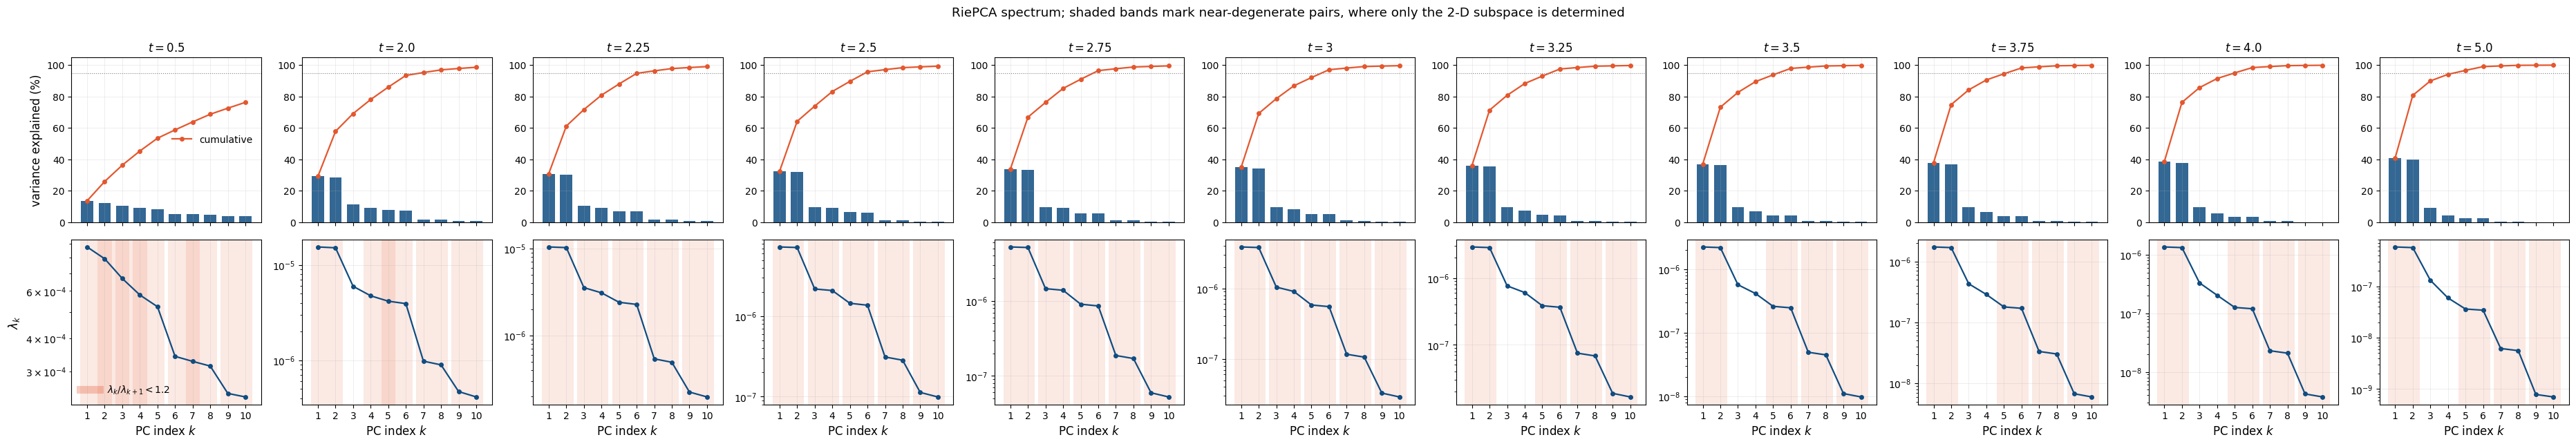

[PosixPath('torus_RiePCA_plots/diagnostics/spectrum.png'),
 PosixPath('torus_RiePCA_plots/diagnostics/spectrum.pdf')]

In [11]:
n = len(T_FIGURES)
fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 6.4), sharex=True)

for j, t in enumerate(T_FIGURES):
    s = spectra[float(t)]
    k = np.arange(1, len(s["share"]) + 1)

    ax = axes[0, j]
    ax.bar(k, s["share"] * 100, color="#0F4C81", alpha=0.85, width=0.7)
    ax.plot(k, s["cumulative"] * 100, "o-", color="#E4572E", ms=4,
            label="cumulative")
    ax.axhline(95, color="0.5", ls=":", lw=0.8)
    ax.set_ylim(0, 105); ax.set_xticks(k)
    ax.set_title(rf"$t={t}$")
    if j == 0:
        ax.set_ylabel("variance explained (%)")
        ax.legend(loc="center right")

    ax = axes[1, j]
    ax.semilogy(k, s["eigenvalues"], "o-", color="#0F4C81", ms=4)
    for kk in np.flatnonzero(s["degenerate"]):
        ax.axvspan(kk + 0.6, kk + 2.4, color="#E4572E", alpha=0.13, lw=0)
    ax.set_xticks(k); ax.set_xlabel("PC index $k$")
    if j == 0:
        ax.set_ylabel(r"$\lambda_k$")

axes[1, 0].plot([], [], color="#E4572E", alpha=0.3, lw=8,
                label=rf"$\lambda_k/\lambda_{{k+1}}<{DEGENERACY_RATIO}$")
axes[1, 0].legend(loc="lower left")
fig.suptitle("RiePCA spectrum; shaded bands mark near-degenerate pairs, "
             "where only the 2-D subspace is determined", y=1.00)
fig.tight_layout()
finalize(fig, "spectrum", subdir="diagnostics")

#### Principal vector fields

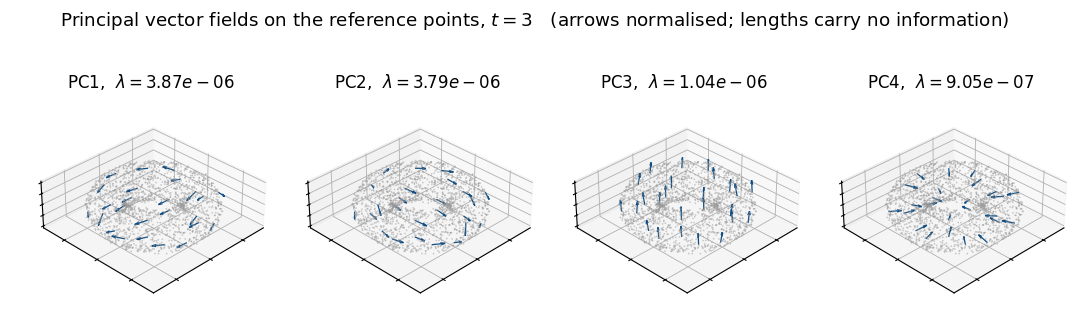

[PosixPath('torus_RiePCA_plots/fields/principal_fields_PC1_PC4_t_3.png'),
 PosixPath('torus_RiePCA_plots/fields/principal_fields_PC1_PC4_t_3.pdf')]

In [12]:
t_show = float(T_FIGURES[5])
fields = pc_fields_dict[t_show]                      # (r, d, k)
eigenvalues = riepca_results["evals_dict"][t_show]
n_show = 4

fig = plt.figure(figsize=(3.3 * n_show, 3.7))
for j in range(n_show):
    ax = fig.add_subplot(1, n_show, j + 1, projection="3d")
    F = fields[..., j]
    ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
               c="0.6", s=1.5, alpha=0.5, edgecolors="none", rasterized=True)
    ax.quiver(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2],
              F[:, 0], F[:, 1], F[:, 2],
              length=0.55, normalize=True, color="#0F4C81", linewidth=0.9,
              arrow_length_ratio=0.35)
    ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=32, azim=45)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(rf"PC{j+1},  $\lambda={eigenvalues[j]:.2e}$")
fig.suptitle(rf"Principal vector fields on the reference points, $t={t_show:g}$"
             "   (arrows normalised; lengths carry no information)", y=1.03)
finalize(fig, f"principal_fields_PC1_PC4_t_{time_tag(t_show)}", subdir="fields")

#### PC Score plots

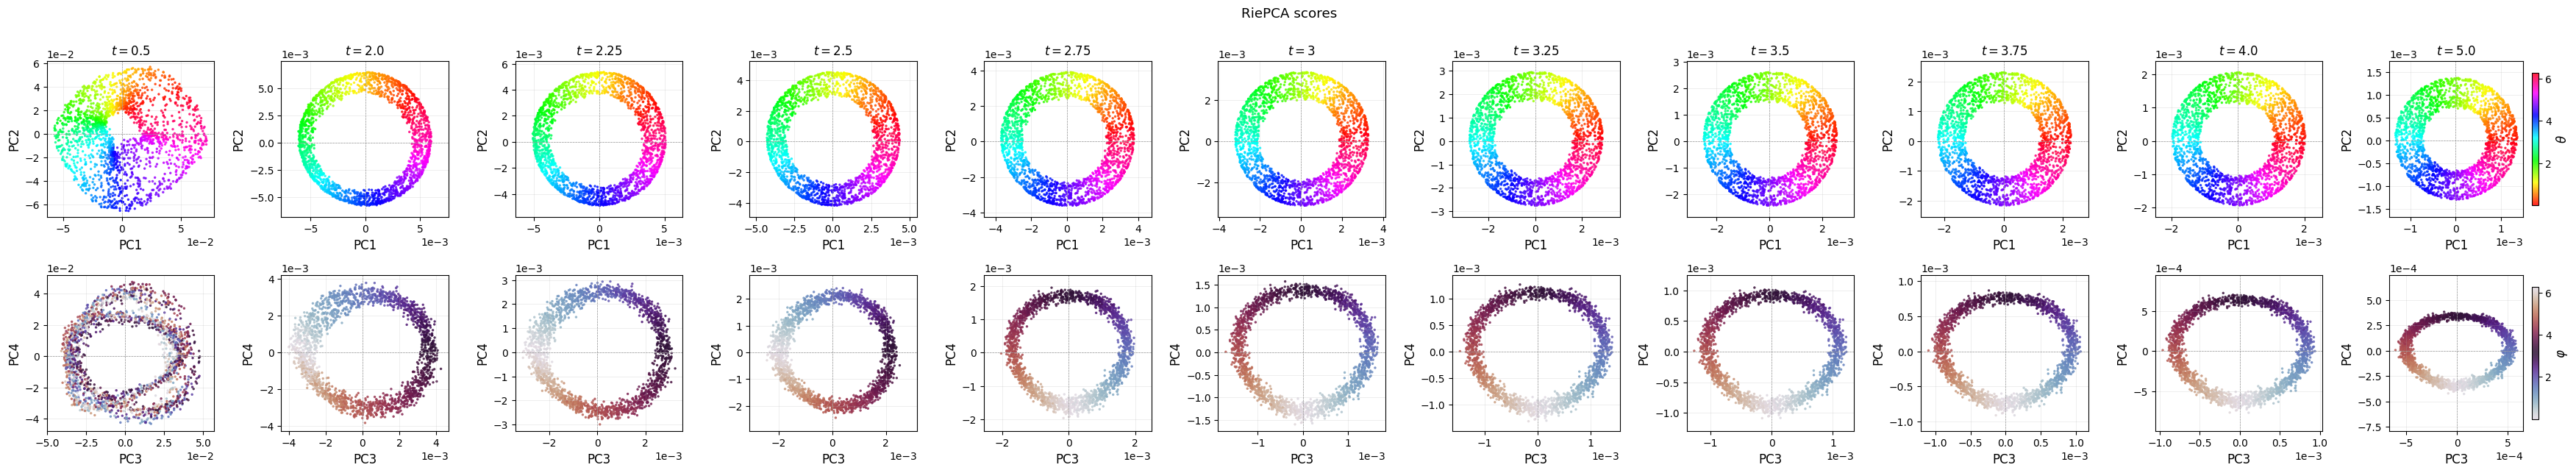

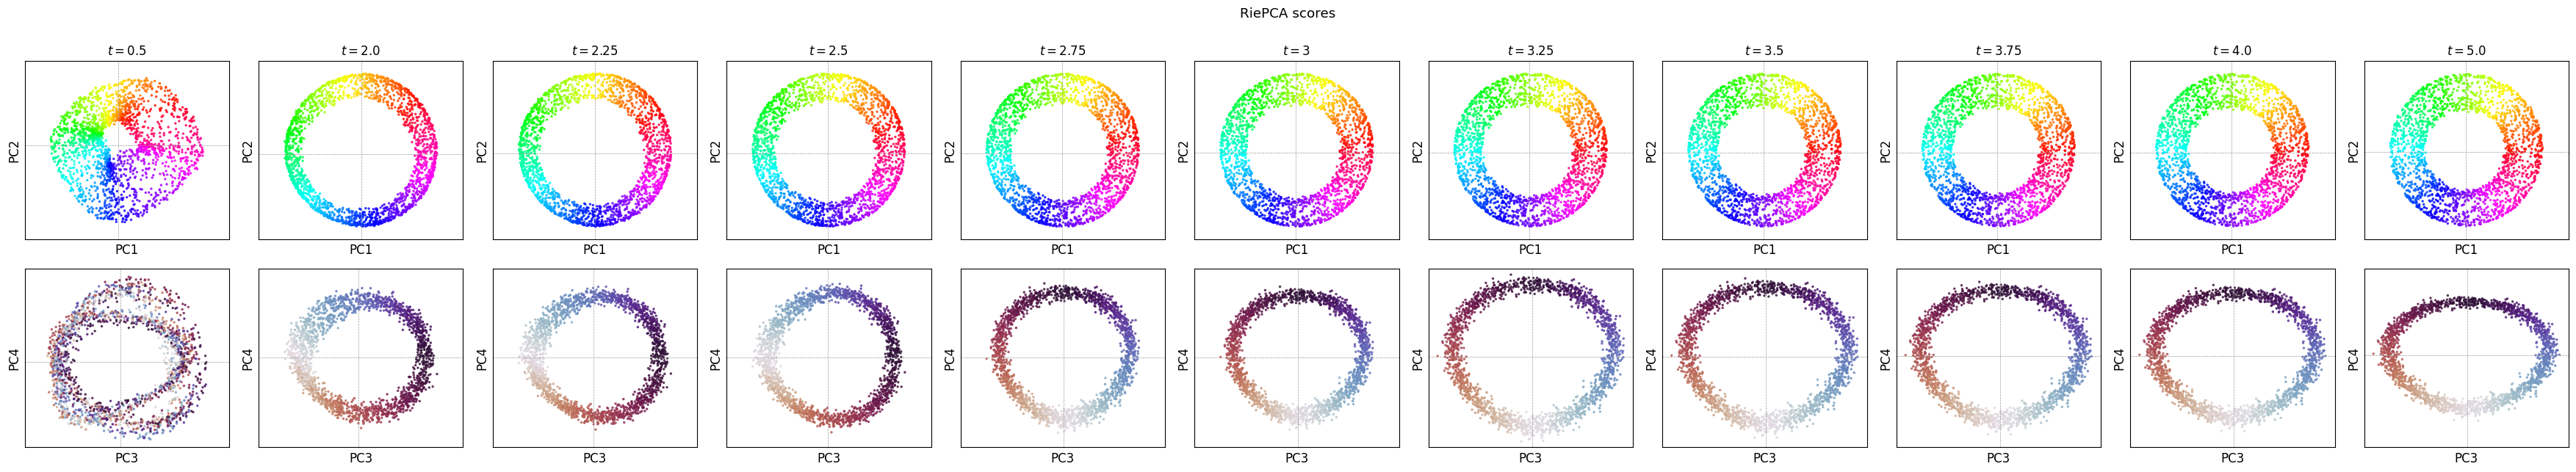

In [13]:
def plot_scores_across_t(times, *, colorbar=True, ticks=True, name="scores"):
    """PC1-PC2 coloured by theta (top) and PC3-PC4 coloured by phi (bottom)."""
    fig, axes = plt.subplots(2, len(times), figsize=(3.2 * len(times), 6.4))
    for j, t in enumerate(times):
        ti = t_values.index(float(t))
        for row, (a, b, colour, cmap, lab) in enumerate([
                (0, 1, theta_values, "hsv", r"$\theta$"),
                (2, 3, phi_values, "twilight", r"$\varphi$")]):
            ax = axes[row, j]
            sc = ax.scatter(projections[:, a, ti], projections[:, b, ti],
                            c=colour, cmap=cmap, s=6, alpha=0.85,
                            edgecolors="none", rasterized=True)
            ax.axhline(0, color="0.6", lw=0.5, ls="--")
            ax.axvline(0, color="0.6", lw=0.5, ls="--")
            ax.set_aspect("equal", adjustable="datalim")
            ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
            if not ticks:
                ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(f"PC{a+1}"); ax.set_ylabel(f"PC{b+1}")
            if row == 0:
                ax.set_title(rf"$t={t}$")
            if colorbar and j == len(times) - 1:
                fig.colorbar(sc, ax=ax, shrink=0.85, label=lab)
    fig.suptitle("RiePCA scores", y=1.00)
    fig.tight_layout()
    finalize(fig, name, subdir="scores")


plot_scores_across_t(T_FIGURES, name="scores_all_figure_times")
plot_scores_across_t(T_FIGURES, colorbar=False, ticks=False,
                     name="scores_all_figure_times_no_colorbar")

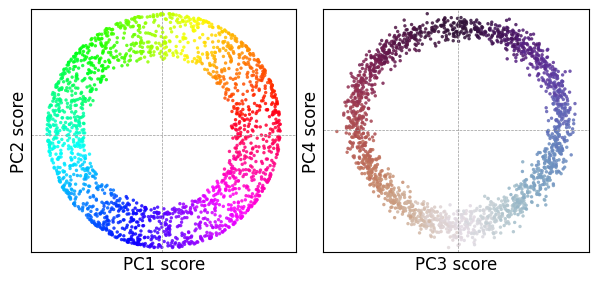

[PosixPath('torus_RiePCA_plots/scores/scores_t_2p75_paper.png'),
 PosixPath('torus_RiePCA_plots/scores/scores_t_2p75_paper.pdf')]

In [14]:
# Paper version: one heat time, the two planes side by side.
t_show = 2.75
ti = t_values.index(t_show)

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
for ax, (a, b, colour, cmap) in zip(axes, [(0, 1, theta_values, "hsv"),
                                           (2, 3, phi_values, "twilight")]):
    ax.scatter(projections[:, a, ti], projections[:, b, ti], c=colour, cmap=cmap,
               s=6, alpha=0.85, edgecolors="none", rasterized=True)
    ax.axhline(0, color="0.6", lw=0.5, ls="--")
    ax.axvline(0, color="0.6", lw=0.5, ls="--")
    ax.set_aspect("equal", adjustable="datalim")
    ax.margins(0.02)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f"PC{a + 1} score", labelpad=2)
    ax.set_ylabel(f"PC{b + 1} score", labelpad=2)

fig.subplots_adjust(left=0.065, right=0.995, bottom=0.12, top=0.88, wspace=0.10)
finalize(fig, f"scores_t_{time_tag(t_show)}_paper", subdir="scores")

#### Cloud coloured by score (i.e., heat map of PC-scores)

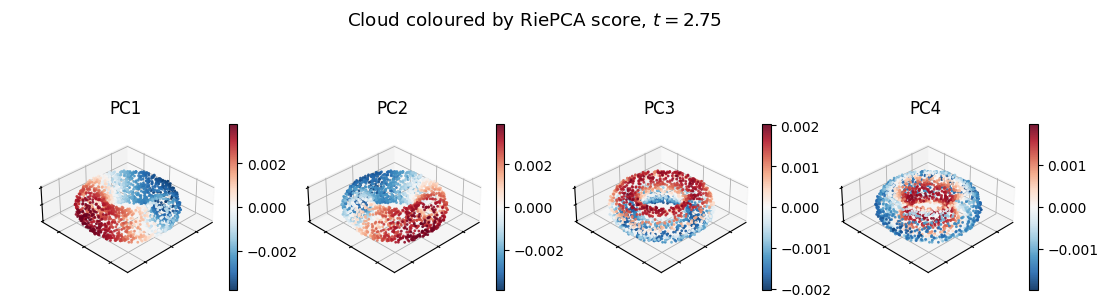

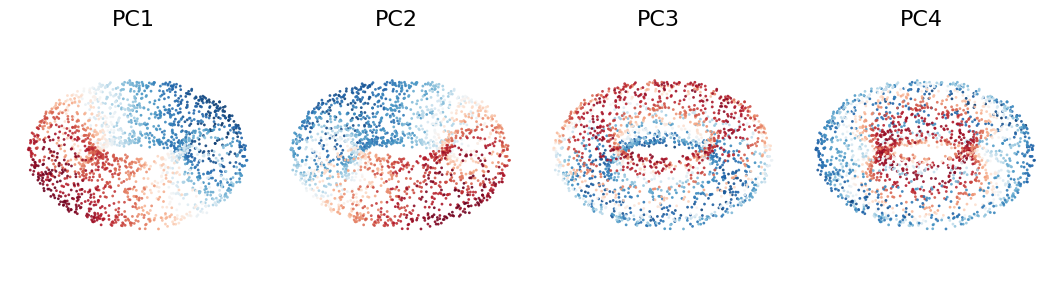

[PosixPath('torus_RiePCA_plots/ambient/ambient_scores_PC1_PC4_t_2p75_paper.png'),
 PosixPath('torus_RiePCA_plots/ambient/ambient_scores_PC1_PC4_t_2p75_paper.pdf')]

In [15]:
t_show = 2.75

ti = t_values.index(t_show)
n_show = 4

# With colorbars.
fig = plt.figure(figsize=(3.3 * n_show, 3.7))
for j in range(n_show):
    v = projections[:, j, ti]
    lim = np.max(np.abs(v))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim) if lim > 0 else None
    ax = fig.add_subplot(1, n_show, j + 1, projection="3d")
    sc = ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
                    c=v, cmap="RdBu_r", norm=norm, s=4, alpha=0.9,
                    edgecolors="none", rasterized=True)
    fig.colorbar(sc, ax=ax, shrink=0.58, pad=0.08)
    ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=32, azim=45)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(f"PC{j+1}")
fig.suptitle(rf"Cloud coloured by RiePCA score, $t={t_show:g}$", y=1.03)
finalize(fig, f"ambient_scores_PC1_PC4_t_{time_tag(t_show)}", subdir="ambient")

# Paper version: nearly edge-to-edge panels, no colorbars.
fig = plt.figure(figsize=(10.5, 2.75))
panel_width = 1.0 / n_show
for j in range(n_show):
    v = projections[:, j, ti]
    lim = np.max(np.abs(v))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim) if lim > 0 else None
    ax = fig.add_axes([j * panel_width, 0.00, panel_width, 0.90], projection="3d")
    ax.scatter(data_points[:, 0], data_points[:, 1], data_points[:, 2],
               c=v, cmap="RdBu_r", norm=norm, s=4, alpha=0.9,
               edgecolors="none", rasterized=True)
    ax.set_axis_off()
    ax.set_facecolor("none")
    ax.set_box_aspect([1, 1, 0.35], zoom=1.3)
    ax.view_init(elev=32, azim=45)
    ax.margins(0)
    ax.set_title(f"PC{j + 1}", pad=-8, fontsize=16)
finalize(fig, f"ambient_scores_PC1_PC4_t_{time_tag(t_show)}_paper", subdir="ambient")

## 2. Baselines: Euclidean PCA and kernel PCA

Both baselines see the same cloud.

Euclidean PCA has only three components because the input data lie in \(\mathbb{R}^3\).

RBF kernel PCA is fitted at $\sigma\in\{0.5,1,2,4\}$ using the kernel

$$
K_\sigma(x,y)=\exp\left(-\frac{\lVert x-y\rVert^2}{2\sigma^2}\right).
$$

For each method, the figures show the fixed adjacent component pairs
1–2, 2–3, ..., 9–10 wherever they are available. The same projections are
coloured first by $\theta$ and then by $\varphi$.

PCA explained variance ratio: [0.4743 0.457  0.0687]


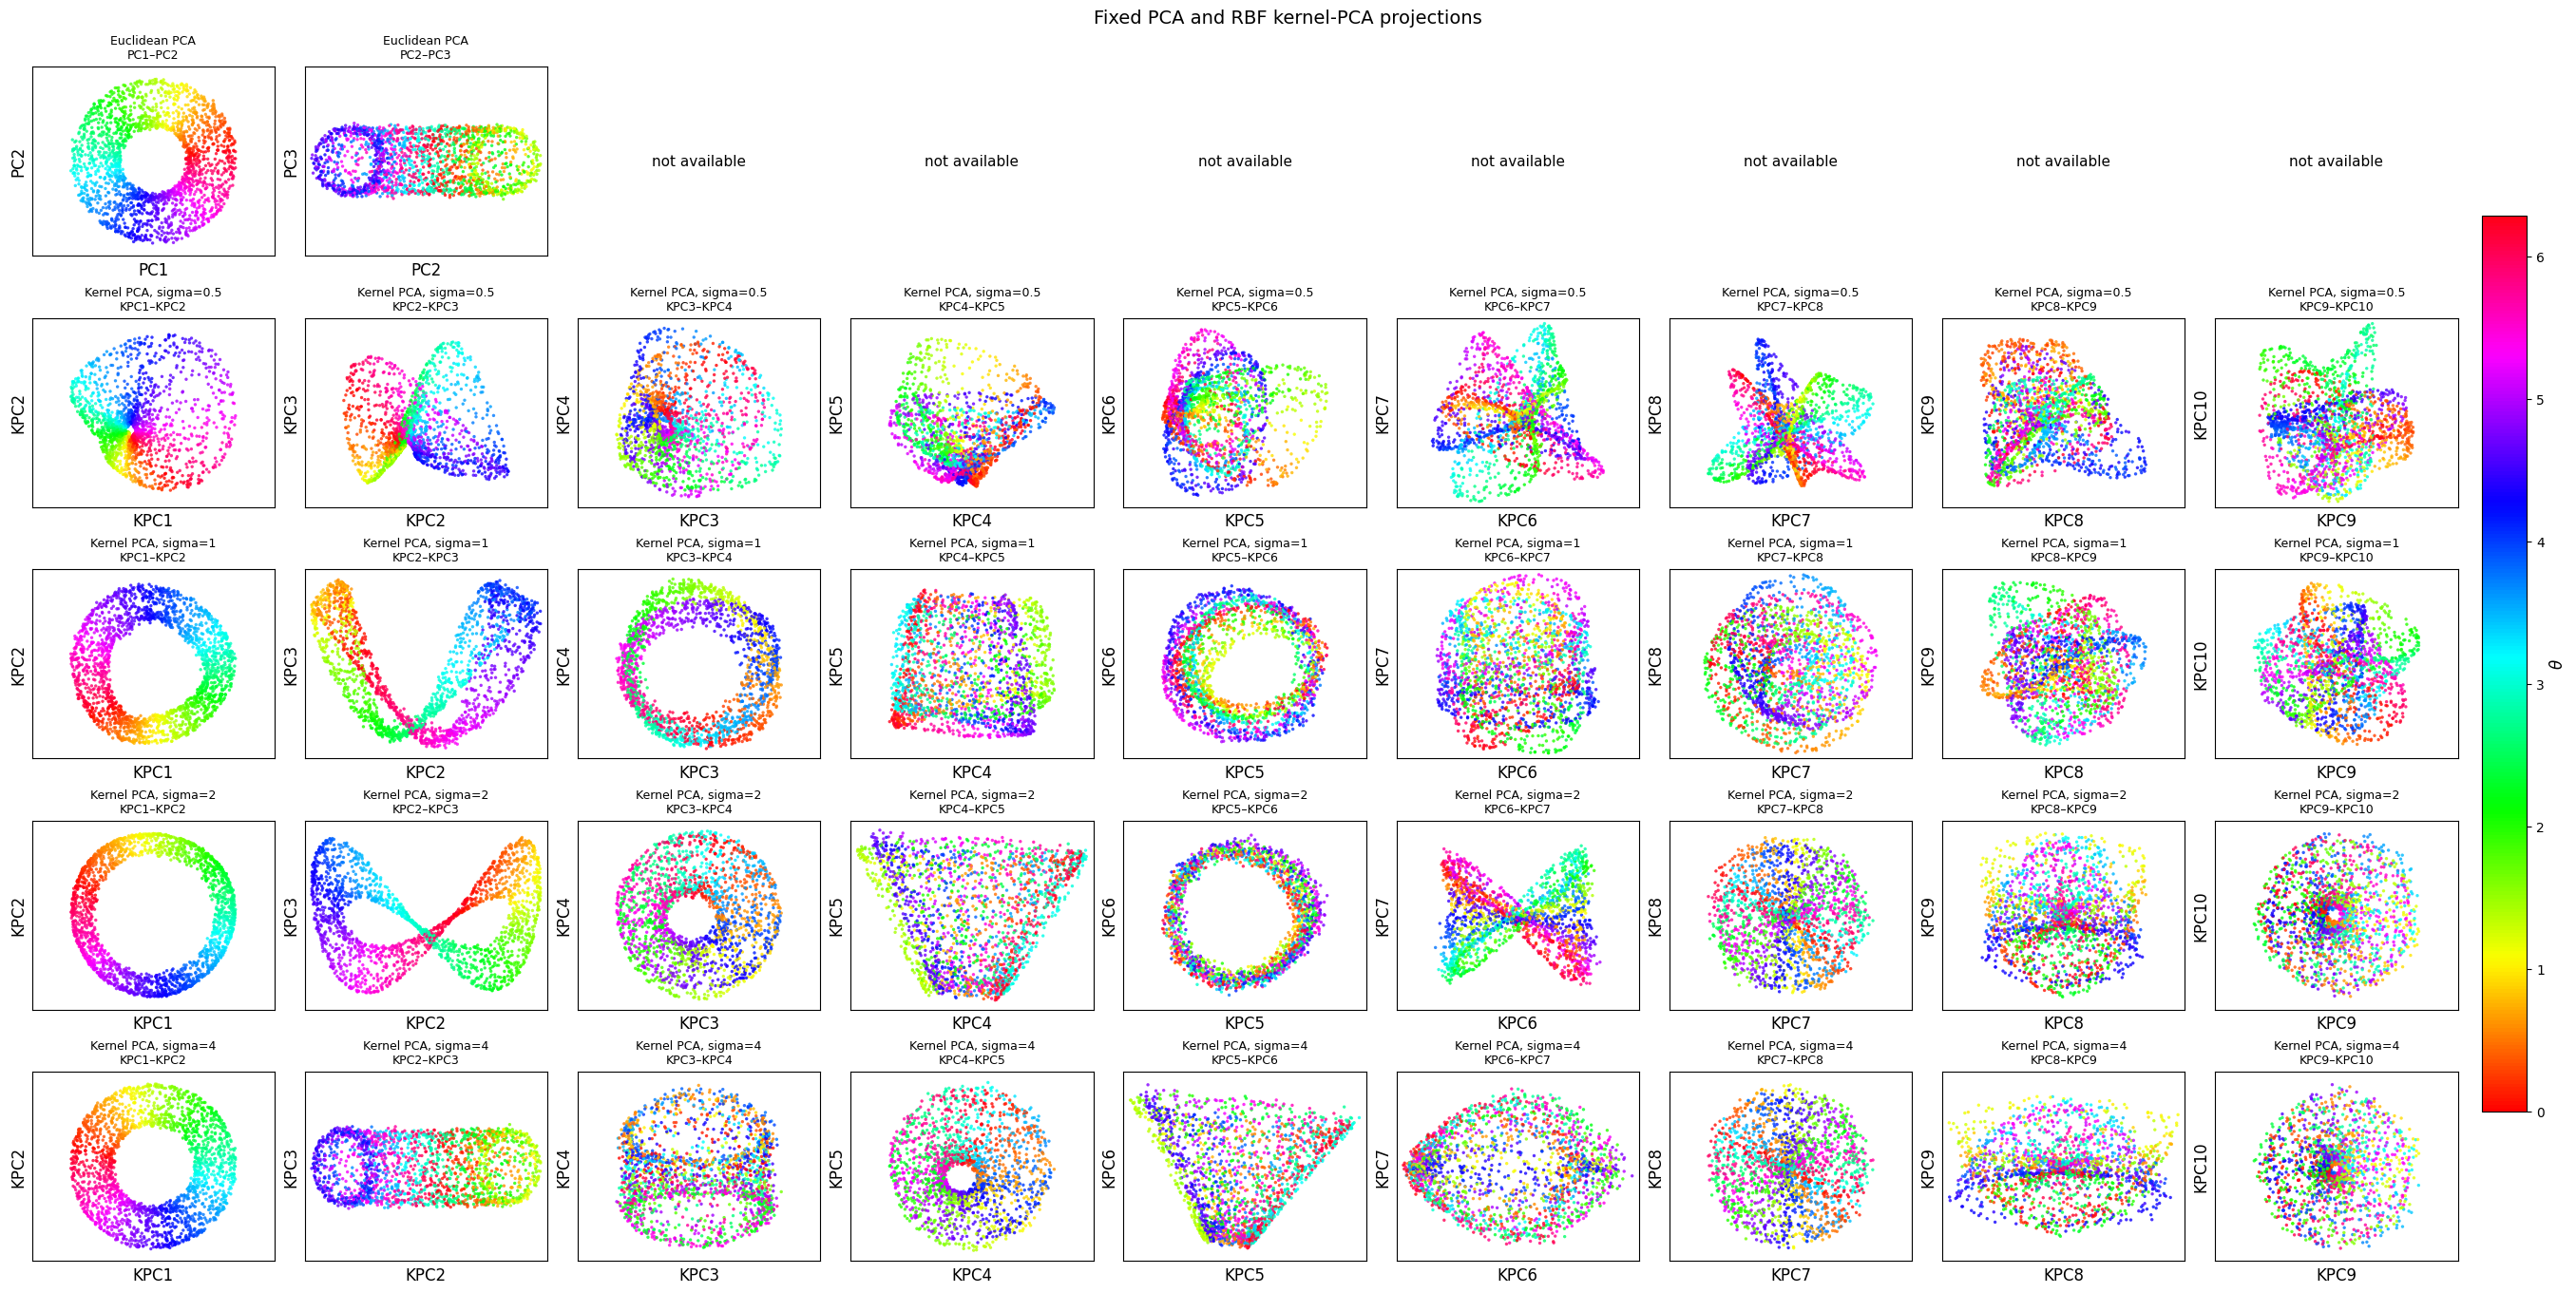

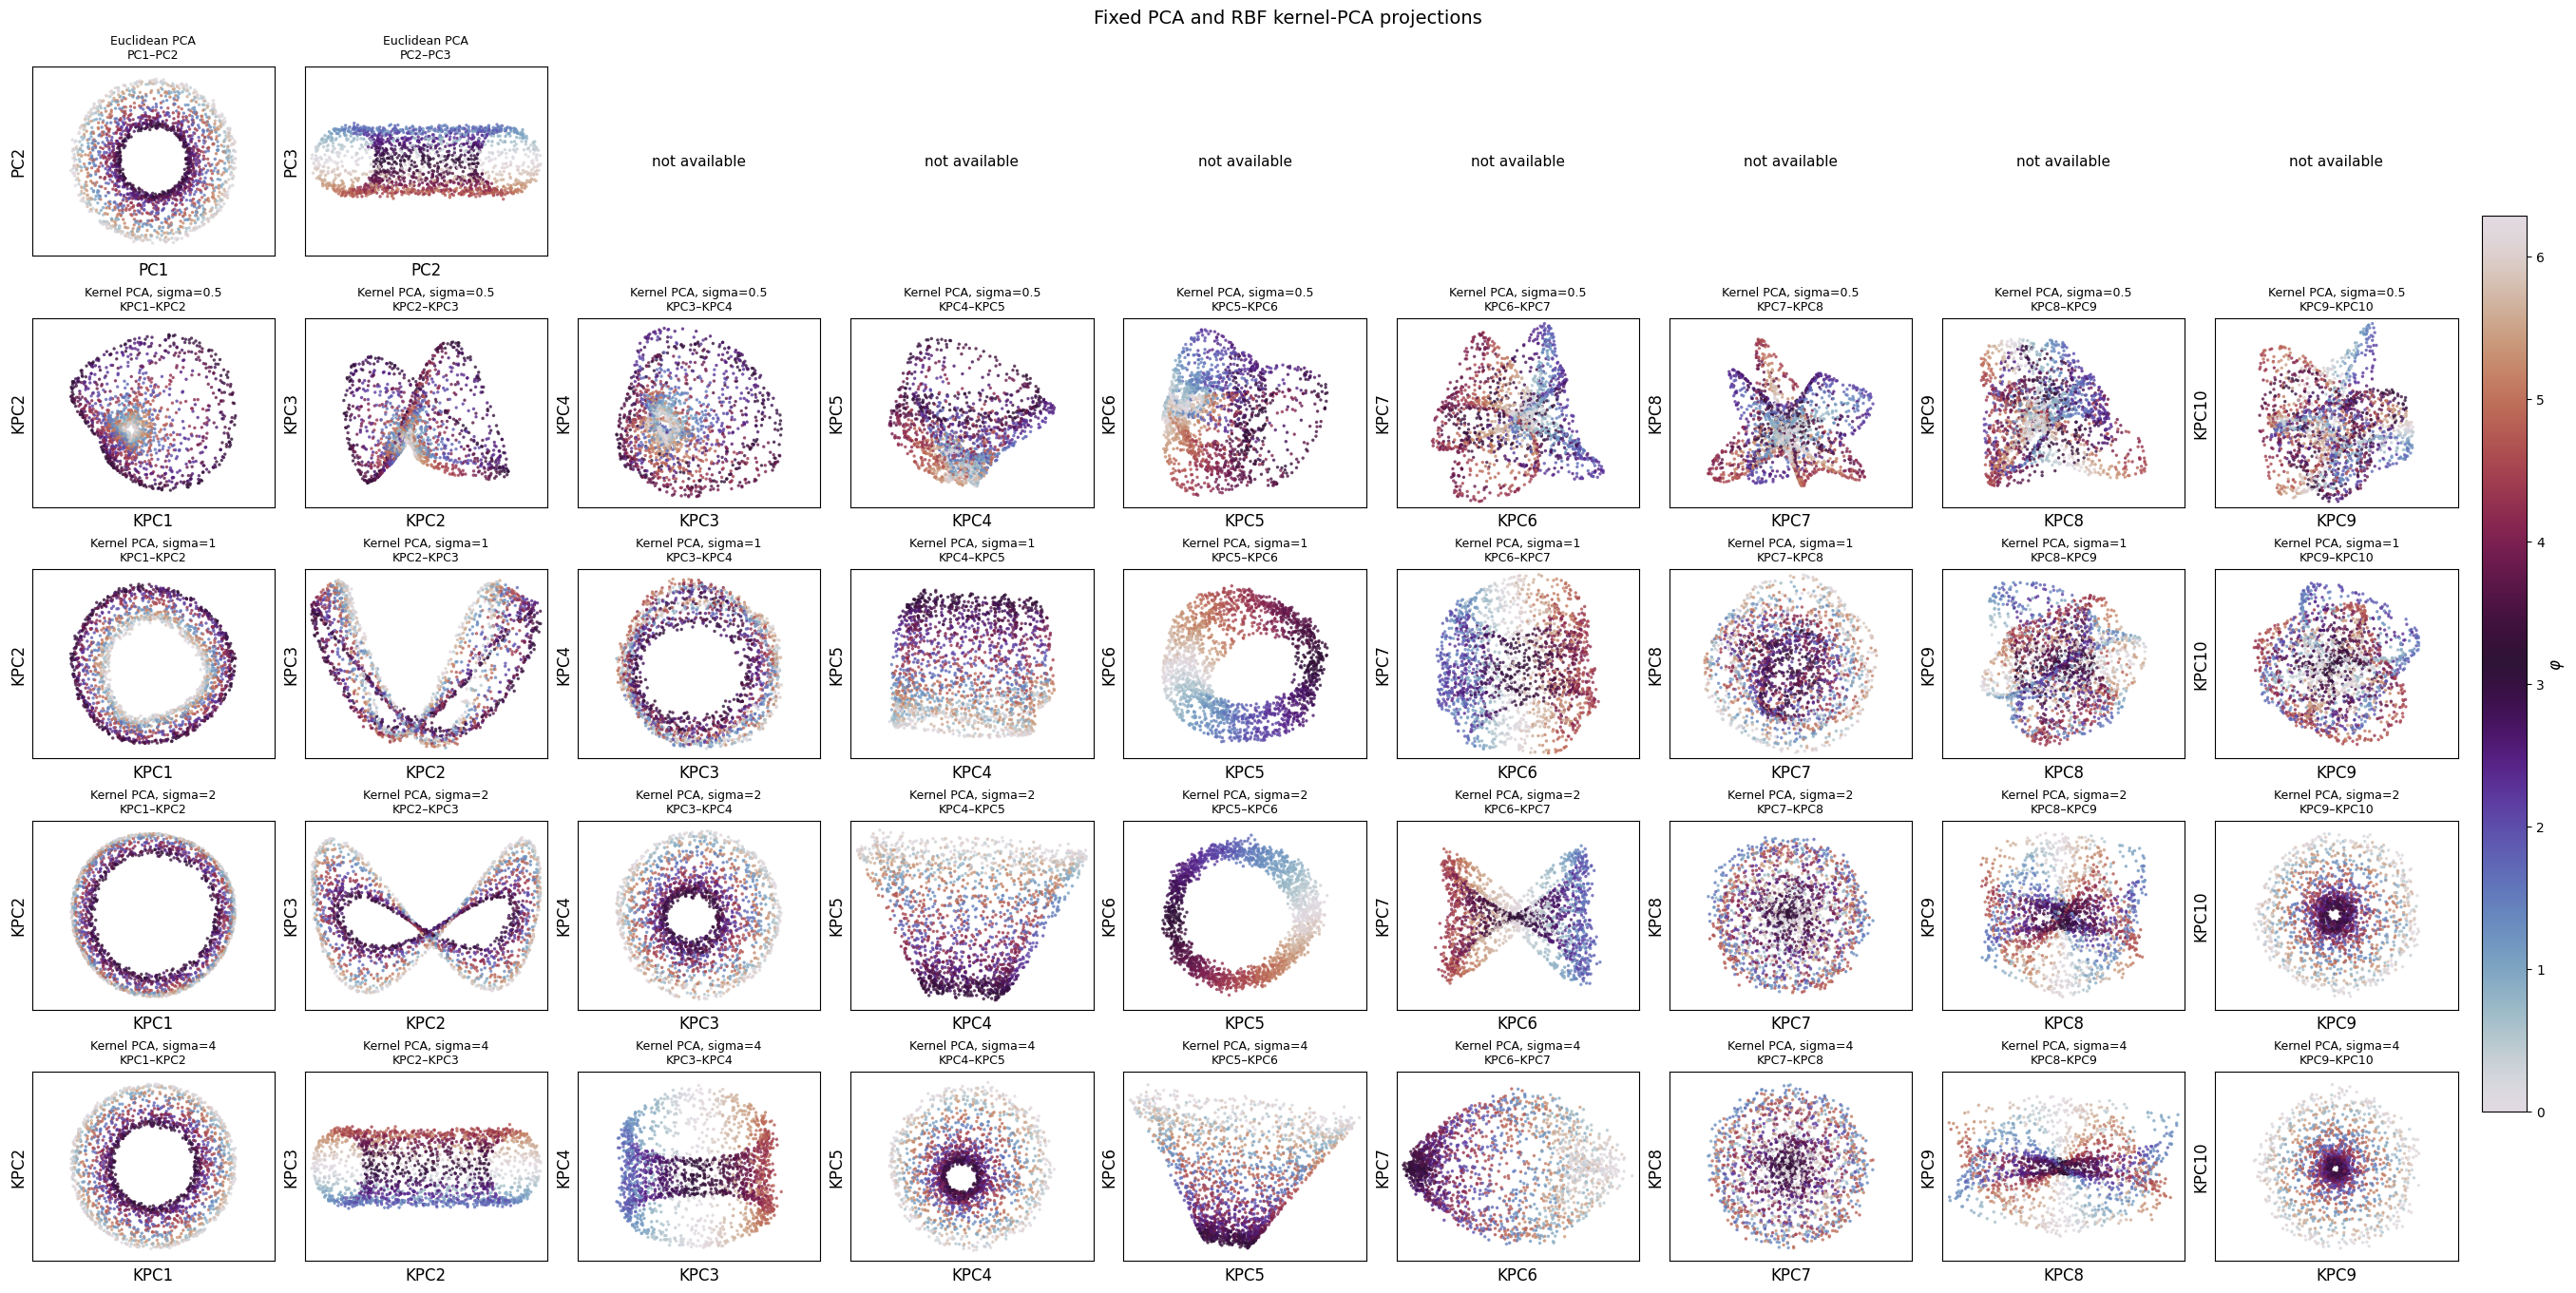

In [16]:
from sklearn.decomposition import PCA, KernelPCA

# Kernel bandwidths to compare
SIGMA_VALUES = (0.5, 1.0, 2.0, 4.0)

# Four components produce first 9 distinct 2-D projections:
N_COMPONENTS_TO_PLOT = 10

component_pairs = [
    (i, i + 1)
    for i in range(N_COMPONENTS_TO_PLOT - 1)
]


# Fit ordinary PCA
# data_points has three columns, so ordinary PCA has at most three PCs.
n_pca_components = min(
    N_COMPONENTS_TO_PLOT,
    data_points.shape[0],
    data_points.shape[1]
)

pca = PCA(
    n_components=n_pca_components,
    svd_solver="full"
)

Y_PCA = pca.fit_transform(data_points)

print(
    "PCA explained variance ratio:",
    np.round(pca.explained_variance_ratio_, 4)
)


# Fit kernel PCA for each sigma
embeddings = [
    ("Euclidean PCA", "PC", Y_PCA)
]

for sigma in SIGMA_VALUES:
    # This gives the kernel:
    # exp(-distance_squared / (2 * sigma_squared))
    gamma = 1.0 / (2.0 * sigma**2)

    kpca = KernelPCA(
        n_components=N_COMPONENTS_TO_PLOT,
        kernel="rbf",
        gamma=gamma,
        eigen_solver="arpack",
        remove_zero_eig=True,
        random_state=RANDOM_SEED
    )

    Y_KPCA = kpca.fit_transform(data_points)

    embeddings.append(
        (f"Kernel PCA, sigma={sigma:g}", "KPC", Y_KPCA)
    )


# Plot every fixed component pair
def plot_pca_kpca_pairs(colour, cmap, colour_label, filename):
    number_of_methods = len(embeddings)
    number_of_pairs = len(component_pairs)

    fig, axes = plt.subplots(
        number_of_methods,
        number_of_pairs,
        figsize=(3.0 * number_of_pairs, 2.7 * number_of_methods),
        squeeze=False,
        constrained_layout=True
    )

    # Both torus angles lie in [0, 2*pi).
    colour_norm = mpl.colors.Normalize(vmin=0.0, vmax=TWO_PI)

    for row, (method_name, prefix, scores) in enumerate(embeddings):
        for column, (first, second) in enumerate(component_pairs):
            ax = axes[row, column]

            # For example, ordinary PCA has no PC4 because the data is 3-D.
            if second >= scores.shape[1]:
                ax.text(
                    0.5,
                    0.5,
                    "not available",
                    ha="center",
                    va="center",
                    transform=ax.transAxes
                )
                ax.set_axis_off()
                continue

            ax.scatter(
                scores[:, first],
                scores[:, second],
                c=colour,
                cmap=cmap,
                norm=colour_norm,
                s=6,
                alpha=0.8,
                edgecolors="none",
                rasterized=True
            )

            ax.set_title(
                f"{method_name}\n"
                f"{prefix}{first + 1}–{prefix}{second + 1}",
                fontsize=9
            )
            ax.set_xlabel(f"{prefix}{first + 1}")
            ax.set_ylabel(f"{prefix}{second + 1}")
            ax.set_aspect("equal", adjustable="datalim")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(False)

    colour_map = mpl.cm.ScalarMappable(
        norm=colour_norm,
        cmap=cmap
    )
    colour_map.set_array([])

    fig.colorbar(
        colour_map,
        ax=axes.ravel().tolist(),
        label=colour_label,
        shrink=0.75,
        pad=0.01
    )

    fig.suptitle(
        "Fixed PCA and RBF kernel-PCA projections",
        fontsize=14
    )

    finalize(
        fig,
        filename,
        subdir="diagnostics"
    )


# Same projections coloured by theta
plot_pca_kpca_pairs(
    theta_values,
    "hsv",
    r"$\theta$",
    "pca_kpca_pairs_theta"
)

# Same projections coloured by phi
plot_pca_kpca_pairs(
    phi_values,
    "twilight",
    r"$\varphi$",
    "pca_kpca_pairs_phi"
)